# Sujet 1 — §1.2 Variables gaussiennes par la méthode de Box et Muller

**Idée** : on ne sait pas inverser la fonction de répartition de $\mathcal N(0,1)$ (pas de formule fermée). En revanche, un **couple** $(X_1, X_2)$ de gaussiennes indépendantes s'écrit simplement en coordonnées polaires : rayon² exponentiel et angle uniforme, deux lois que l'on sait générer par inversion.

Démonstrations complètes : [demonstrations.md](https://github.com/Este34/presentation_statistique/blob/main/sujets/sujet1/demonstrations.md). Code : [generateurs.py](https://github.com/Este34/presentation_statistique/blob/main/src/stats_td/generateurs.py).

In [1]:
import json, sys
from pathlib import Path
sys.path.insert(0, str(Path("../../src").resolve()))

import numpy as np
import matplotlib.pyplot as plt
from stats_td.figures import style, sauver, BLEU, ORANGE
from stats_td.generateurs import exponentielle_inversion, box_muller, gaussienne
from stats_td.empirique import (repartition_complementaire, repartition_histogramme,
                                pente_semilog)

style()
FIG = Path("figures")
rng = np.random.default_rng(2026)  # graine fixée : résultats reproductibles
RESULTATS = FIG / "resultats.json"
resultats = json.loads(RESULTATS.read_text()) if RESULTATS.exists() else {}

## Q1 — $Z = X_1^2 + X_2^2$ suit $\mathcal E(1/2)$

$$P(Z \ge z) = \iint_{x_1^2 + x_2^2 \ge z} \frac{1}{2\pi} e^{-\frac{x_1^2 + x_2^2}{2}}\,dx_1\,dx_2$$

Changement de variables polaire $x_1 = r\cos\theta,\ x_2 = r\sin\theta$, $dx_1\,dx_2 = r\,dr\,d\theta$ (Jacobien $r$), domaine $r \ge \sqrt z$ :

$$P(Z \ge z) = \int_0^{2\pi}\!\!\int_{\sqrt z}^{+\infty} \frac{1}{2\pi} e^{-r^2/2}\, r\,dr\,d\theta = \Big[-e^{-r^2/2}\Big]_{\sqrt z}^{+\infty} = e^{-z/2} \quad (z \ge 0).$$

C'est la fonction de répartition complémentaire de $\mathcal E(\lambda = 1/2)$ (moyenne 2).
> Coquille dans l'énoncé : il écrit $\exp(-2z)$ alors qu'on trouve bien $\exp(-z/2)$, cohérent avec $\lambda = 1/2$.

Vérification numérique avec le générateur de référence de numpy (l'équivalent de `randn`) :

moyenne de Z = 2.019 (attendu 2)   pente semi-log = -0.504 (attendu -0.5)


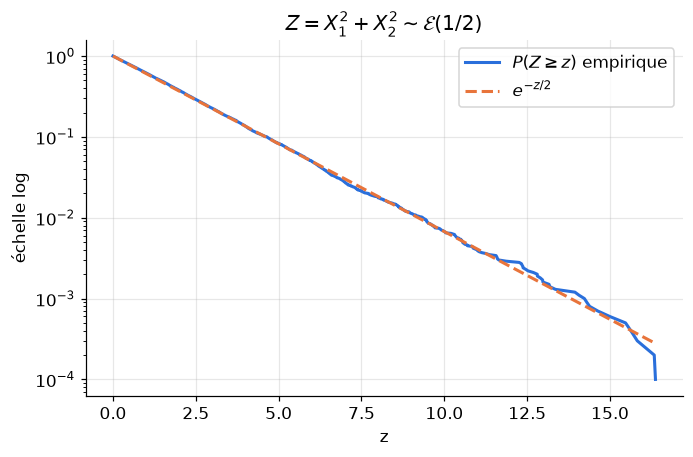

In [2]:
T = 10_000
X1_ref, X2_ref = rng.standard_normal(T), rng.standard_normal(T)   # randn de référence
Z = X1_ref**2 + X2_ref**2
z_tri, Fc = repartition_complementaire(Z)
pente, _ = pente_semilog(Z)

fig, ax = plt.subplots()
ax.semilogy(z_tri, Fc, color=BLEU, lw=2, label=r"$P(Z \geq z)$ empirique")
ax.semilogy(z_tri, np.exp(-z_tri / 2), "--", color=ORANGE, lw=2, label=r"$e^{-z/2}$")
ax.set(xlabel="z", ylabel="échelle log", title=r"$Z = X_1^2 + X_2^2 \sim \mathcal{E}(1/2)$")
ax.legend()
sauver(fig, FIG / "s12_Z_semilog.png")
print(f"moyenne de Z = {Z.mean():.3f} (attendu 2)   pente semi-log = {pente:.3f} (attendu -0.5)")

## Q2 — $r^2 \sim \mathcal E(1/2)$ et $\theta \sim \mathcal U[0, 2\pi]$, indépendants

$r^2 = X_1^2 + X_2^2 = Z$, donc $r^2 \sim \mathcal E(1/2)$ d'après Q1.

Pour $\theta$ : la densité du couple $\frac{1}{2\pi}e^{-(x_1^2+x_2^2)/2}$ ne dépend que de la distance à l'origine (**symétrie de rotation**). En polaires, la densité de $(r, \theta)$ est

$$f_{r,\theta}(r, \theta) = \underbrace{r e^{-r^2/2}}_{\text{ne dépend que de } r} \times \underbrace{\frac{1}{2\pi}\mathbb 1_{[0,2\pi]}(\theta)}_{\text{ne dépend que de } \theta}$$

Elle se **factorise** : $r$ et $\theta$ sont indépendants et $\theta$ est uniforme sur $[0, 2\pi]$.

corrélation(r², θ) = -0.0130  (≈ 0 : cohérent avec l'indépendance)


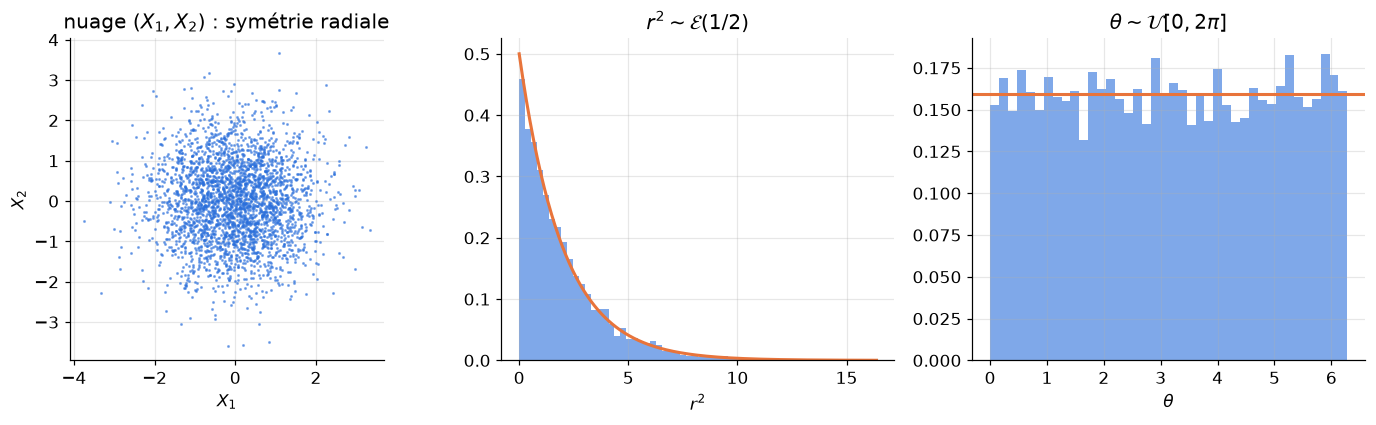

In [3]:
theta = np.mod(np.arctan2(X2_ref, X1_ref), 2 * np.pi)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].plot(X1_ref[:3000], X2_ref[:3000], ".", ms=2, color=BLEU, alpha=0.5)
axes[0].set(aspect="equal", xlabel="$X_1$", ylabel="$X_2$", title="nuage $(X_1, X_2)$ : symétrie radiale")
axes[1].hist(Z, bins=60, density=True, color=BLEU, alpha=0.6)
zz = np.linspace(0, Z.max(), 300)
axes[1].plot(zz, 0.5 * np.exp(-zz / 2), color=ORANGE, lw=2)
axes[1].set(xlabel="$r^2$", title=r"$r^2 \sim \mathcal{E}(1/2)$")
axes[2].hist(theta, bins=40, density=True, color=BLEU, alpha=0.6)
axes[2].axhline(1 / (2 * np.pi), color=ORANGE, lw=2)
axes[2].set(xlabel=r"$\theta$", title=r"$\theta \sim \mathcal{U}[0, 2\pi]$")
fig.tight_layout()
sauver(fig, FIG / "s12_polaire.png")
print(f"corrélation(r², θ) = {np.corrcoef(Z, theta)[0, 1]:+.4f}  (≈ 0 : cohérent avec l'indépendance)")

## Q3 — Méthode de génération (Box-Muller)

On fait le chemin inverse : on génère $(r, \theta)$ puis on revient en cartésiennes.
1. $U_1, U_2 \sim \mathcal U[0,1]$ indépendantes.
2. $r^2 = -2\ln U_1$ : inversion de $\mathcal E(1/2)$ (Q2 du §1.1 avec $\lambda = 1/2$).
3. $\theta = 2\pi U_2$ : uniforme sur $[0, 2\pi]$.
4. $X_1 = \sqrt{-2\ln U_1}\,\cos(2\pi U_2)$ et $X_2 = \sqrt{-2\ln U_1}\,\sin(2\pi U_2)$.

On obtient **deux** gaussiennes indépendantes pour deux uniformes.

In [4]:
X1, X2 = box_muller(T, rng)    # voir src/stats_td/generateurs.py
print(f"X1 : moyenne {X1.mean():+.4f}  variance {X1.var(ddof=1):.4f}")
print(f"X2 : moyenne {X2.mean():+.4f}  variance {X2.var(ddof=1):.4f}")
print(f"corrélation(X1, X2) = {np.corrcoef(X1, X2)[0, 1]:+.4f}")

X1 : moyenne +0.0024  variance 0.9959
X2 : moyenne +0.0004  variance 0.9812
corrélation(X1, X2) = -0.0012


## Q4 — Transformation linéaire : de $\mathcal N(0,1)$ à $\mathcal N(\mu, \sigma^2)$

Si $X \sim \mathcal N(0,1)$, alors $Y = \mu + \sigma X \sim \mathcal N(\mu, \sigma^2)$ ($\mathbb E[Y] = \mu$, $\operatorname{Var}(Y) = \sigma^2 \operatorname{Var}(X) = \sigma^2$, et une transformation affine d'une gaussienne reste gaussienne).

⚠️ Pour $\mathcal N(\mu = 5, \sigma^2 = 4)$, on multiplie par l'**écart-type** $\sigma = 2$, pas par 4.

In [5]:
MU, SIGMA2 = 5.0, 4.0
Y = gaussienne(MU, SIGMA2, T, rng)   # Y = MU + sqrt(SIGMA2) * X, X par Box-Muller

## Q5 — Vérification : moyenne, variance, histogramme

moyenne  : empirique 4.9973   théorique 5.0   (erreur-type σ/√T = 0.020)
variance : empirique 3.8865   théorique 4.0


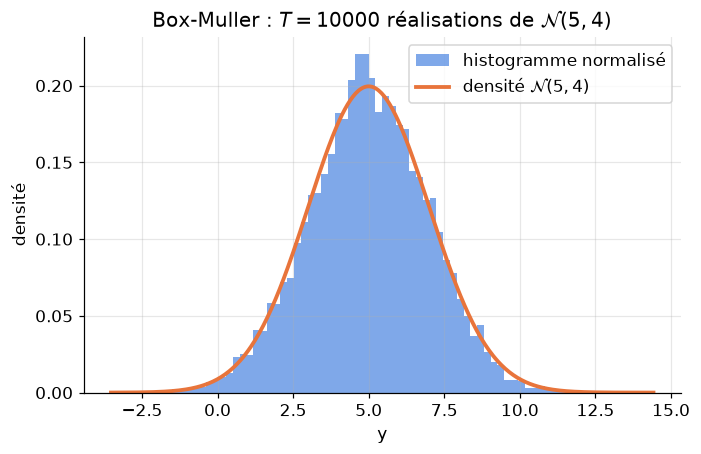

In [6]:
moy, var = Y.mean(), Y.var(ddof=1)
print(f"moyenne  : empirique {moy:.4f}   théorique {MU}   (erreur-type σ/√T = {np.sqrt(SIGMA2/T):.3f})")
print(f"variance : empirique {var:.4f}   théorique {SIGMA2}")
resultats["gauss"] = {"mu": MU, "sigma2": SIGMA2, "T": T, "moyenne": moy, "variance": var}

fig, ax = plt.subplots()
ax.hist(Y, bins=80, density=True, color=BLEU, alpha=0.6, label="histogramme normalisé")
yy = np.linspace(Y.min(), Y.max(), 400)
ax.plot(yy, np.exp(-(yy - MU)**2 / (2 * SIGMA2)) / np.sqrt(2 * np.pi * SIGMA2), color=ORANGE, lw=2.5,
        label=r"densité $\mathcal{N}(5, 4)$")
ax.set(xlabel="y", ylabel="densité", title=rf"Box-Muller : $T={T}$ réalisations de $\mathcal{{N}}(5, 4)$")
ax.legend()
sauver(fig, FIG / "s12_hist_N5_4.png")
_ = RESULTATS.write_text(json.dumps(resultats, indent=2))  # _ = : n'affiche pas le nombre de caractères écrits

**Commentaire.** Moyenne et variance empiriques sont cohérentes avec $\mu = 5$ et $\sigma^2 = 4$ :
- moyenne : l'erreur-type vaut $\sigma/\sqrt{T} = 0{,}02$, et l'écart observé est bien plus petit ;
- variance : pour une gaussienne, la variance empirique a pour écart-type $\sigma^2\sqrt{2/(T-1)} \approx 0{,}057$. L'écart observé (−0,11) vaut 2,01 écarts-types : **juste à la limite** des 95 % ($p \approx 4{,}5\,\%$), comme la moyenne du §1.1. On ne rejette pas au seuil de 1 %, et la moyenne, l'histogramme et le [test KS](https://github.com/Este34/presentation_statistique/blob/main/tests/test_generateurs.py#L57) sont bons : c'est une fluctuation (changer la graine donne d'autres valeurs autour de 4). L'histogramme normalisé épouse la cloche théorique centrée en 5, dont la largeur caractéristique vaut $\sigma = 2$.